# **Mounting OneDrive**



In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Unzipping** **data**

In [50]:
!unzip -q -n "/content/drive/MyDrive/Colab Notebooks/vehicle.zip" # unzipping dataset

# **Importing Keras**

In [51]:
!pip install --upgrade git+https://github.com/davin11/easy-cv-dataset keras-cv

  Cloning https://github.com/davin11/easy-cv-dataset to /tmp/pip-req-build-nhw2ji34
  Running command git clone --filter=blob:none --quiet https://github.com/davin11/easy-cv-dataset /tmp/pip-req-build-nhw2ji34
  Resolved https://github.com/davin11/easy-cv-dataset to commit f7d6ea12c1108495ea882f7840013fd2ff2fb502
  Preparing metadata (setup.py) ... done


# **Reading images from directories**

In [52]:
from easy_cv_dataset import image_dataframe_from_directory, image_classification_dataset_from_dataframe

In [53]:
# Generate DataFrames containing image file paths and corresponding labels
# Returns a DataFrame with two columns: 'image' (file path) and 'label' (class name).

train_df =image_dataframe_from_directory("/content/vehicle/Training")
val_df = image_dataframe_from_directory("/content/vehicle/Validation")
test_df = image_dataframe_from_directory("/content/vehicle/Testing")

In [54]:
#Displaying the Dataframes
display(train_df)
display(val_df)
display(test_df)

,image,class
0,/content/vehicle/Training/Auto Rickshaws/Auto ...,Auto Rickshaws
1,/content/vehicle/Training/Auto Rickshaws/Auto ...,Auto Rickshaws
2,/content/vehicle/Training/Auto Rickshaws/Auto ...,Auto Rickshaws
3,/content/vehicle/Training/Auto Rickshaws/Auto ...,Auto Rickshaws
4,/content/vehicle/Training/Auto Rickshaws/Auto ...,Auto Rickshaws
...,...,...
3907,/content/vehicle/Training/Trains/Train (95).jpg,Trains
3908,/content/vehicle/Training/Trains/Train (96).jpg,Trains
3909,/content/vehicle/Training/Trains/Train (97).png,Trains
3910,/content/vehicle/Training/Trains/Train (98).png,Trains


,image,class
0,/content/vehicle/Validation/Auto Rickshaws/Aut...,Auto Rickshaws
1,/content/vehicle/Validation/Auto Rickshaws/Aut...,Auto Rickshaws
2,/content/vehicle/Validation/Auto Rickshaws/Aut...,Auto Rickshaws
3,/content/vehicle/Validation/Auto Rickshaws/Aut...,Auto Rickshaws
4,/content/vehicle/Validation/Auto Rickshaws/Aut...,Auto Rickshaws
...,...,...
833,/content/vehicle/Validation/Trains/Train (676)...,Trains
834,/content/vehicle/Validation/Trains/Train (677)...,Trains
835,/content/vehicle/Validation/Trains/Train (678)...,Trains
836,/content/vehicle/Validation/Trains/Train (679)...,Trains


,image,class
0,/content/vehicle/Testing/Auto Rickshaws/Auto R...,Auto Rickshaws
1,/content/vehicle/Testing/Auto Rickshaws/Auto R...,Auto Rickshaws
2,/content/vehicle/Testing/Auto Rickshaws/Auto R...,Auto Rickshaws
3,/content/vehicle/Testing/Auto Rickshaws/Auto R...,Auto Rickshaws
4,/content/vehicle/Testing/Auto Rickshaws/Auto R...,Auto Rickshaws
...,...,...
832,/content/vehicle/Testing/Trains/Train (796).jpg,Trains
833,/content/vehicle/Testing/Trains/Train (797).png,Trains
834,/content/vehicle/Testing/Trains/Train (798).png,Trains
835,/content/vehicle/Testing/Trains/Train (799).png,Trains


# **Cleaning the Data frames**

In [55]:
from skimage import io
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

# Check training data for corrupted images
corrupted_train_files = []
for index, row in train_df.iterrows():
    try:
        # Access the 'image' column to get the file path
        img_path = row['image']
        img = Image.open(img_path)
        img.load()
        assert not (img.mode=='CMYK')
        assert not (img.format=='WEBP')
    except Exception as e:
        # Use the img_path variable in the print statement and when appending
        print(f"Error reading file: {img_path}, Error: {img.format}")
        corrupted_train_files.append(img_path)

# Check validation data for corrupted images
corrupted_val_files = []
for index, row in val_df.iterrows():
    try:
        # Access the 'image' column to get the file path
        img_path = row['image']
        img = Image.open(img_path)
        img.load()
        assert not (img.mode=='CMYK')
        assert not (img.format=='WEBP')
    except Exception as e:
        # Use the img_path variable in the print statement and when appending
        print(f"Error reading file: {img_path}, Error: {img.mode}")
        corrupted_val_files.append(img_path)

# Check testing data for corrupted images
corrupted_test_files = []
for index, row in test_df.iterrows():
    try:
        # Access the 'image' column to get the file path
        img_path = row['image']
        img = Image.open(img_path)
        img.load()
        assert not (img.mode=='CMYK')
        assert not (img.format=='WEBP')
        assert not (img.format=='str')
    except Exception as e:
        # Use the img_path variable in the print statement and when appending
        print(f"Error reading file: {img_path}, Error: {e}")
        corrupted_test_files.append(img_path)

#Printing the Corrupted images
print("\nCorrupted files found in training data:")
for f in corrupted_train_files:
    print(f)

print("\nCorrupted files found in validation data:")
for f in corrupted_val_files:
    print(f)

print("\nCorrupted files found in testing data:")
for f in corrupted_test_files:
    print(f)

#Remove the Corrupted files from the data frames to make cleaned data frames
# Filter based on the 'image' column

train_df_cleaned = train_df[~train_df['image'].isin(corrupted_train_files)]
val_df_cleaned = val_df[~val_df['image'].isin(corrupted_val_files)]
test_df_cleaned = test_df[~test_df['image'].isin(corrupted_test_files)]

Error reading file: /content/vehicle/Training/Auto Rickshaws/Auto Rickshaw (151).jpg, Error: WEBP
Error reading file: /content/vehicle/Training/Auto Rickshaws/Auto Rickshaw (226).jpg, Error: WEBP
Error reading file: /content/vehicle/Training/Auto Rickshaws/Auto Rickshaw (262).png, Error: WEBP
Error reading file: /content/vehicle/Training/Auto Rickshaws/Auto Rickshaw (276).jpg, Error: WEBP
Error reading file: /content/vehicle/Training/Auto Rickshaws/Auto Rickshaw (313).jpg, Error: WEBP
Error reading file: /content/vehicle/Training/Auto Rickshaws/Auto Rickshaw (315).jpg, Error: WEBP
Error reading file: /content/vehicle/Training/Auto Rickshaws/Auto Rickshaw (385).png, Error: WEBP
Error reading file: /content/vehicle/Training/Auto Rickshaws/Auto Rickshaw (418).jpg, Error: WEBP
Error reading file: /content/vehicle/Training/Auto Rickshaws/Auto Rickshaw (421).jpg, Error: WEBP
Error reading file: /content/vehicle/Training/Auto Rickshaws/Auto Rickshaw (429).jpg, Error: WEBP
Error reading file: 

In [56]:
# Define a function to identify corrupted or unsupported image files in a dataset.
# It attempts to open each image and validate its mode and format.
# If an image fails to load or doesn't meet the expected criteria, it is flagged as corrupted.
def find_corrupted_images(df, name):
    corrupted_files = []
    for _, row in df.iterrows():
        img_path = row['image']
        try:
            img = Image.open(img_path)
            img.load()
            assert img.mode == 'RGB'
            assert img.format in ['JPEG', 'PNG', 'BMP', 'GIF','jpg']
        except Exception as e:
            print(f"[{name}] Corrupt or unsupported file: {img_path} — {e}")
            corrupted_files.append(img_path)
    return corrupted_files

corrupted_test_files = find_corrupted_images(test_df, "Test")

# Clean datasets
test_df_cleaned = test_df[~test_df['image'].isin(corrupted_test_files)]


[Test] Corrupt or unsupported file: /content/vehicle/Testing/Auto Rickshaws/Auto Rickshaw (696).jpg — 
[Test] Corrupt or unsupported file: /content/vehicle/Testing/Auto Rickshaws/Auto Rickshaw (730).jpg — 
[Test] Corrupt or unsupported file: /content/vehicle/Testing/Auto Rickshaws/Auto Rickshaw (735).PNG — 
[Test] Corrupt or unsupported file: /content/vehicle/Testing/Auto Rickshaws/Auto Rickshaw (736).PNG — 
[Test] Corrupt or unsupported file: /content/vehicle/Testing/Auto Rickshaws/Auto Rickshaw (745).PNG — 
[Test] Corrupt or unsupported file: /content/vehicle/Testing/Auto Rickshaws/Auto Rickshaw (770).PNG — 
[Test] Corrupt or unsupported file: /content/vehicle/Testing/Auto Rickshaws/Auto Rickshaw (776).PNG — 
[Test] Corrupt or unsupported file: /content/vehicle/Testing/Motorcycles/Motorcycle (797).jpg — 
[Test] Corrupt or unsupported file: /content/vehicle/Testing/Ships/Ship (687).png — 
[Test] Corrupt or unsupported file: /content/vehicle/Testing/Ships/Ship (750).png — 


In [57]:
#Displaying the cleaned Data frames
display(train_df_cleaned)
display(val_df_cleaned)
display(test_df_cleaned)

,image,class
0,/content/vehicle/Training/Auto Rickshaws/Auto ...,Auto Rickshaws
1,/content/vehicle/Training/Auto Rickshaws/Auto ...,Auto Rickshaws
2,/content/vehicle/Training/Auto Rickshaws/Auto ...,Auto Rickshaws
3,/content/vehicle/Training/Auto Rickshaws/Auto ...,Auto Rickshaws
4,/content/vehicle/Training/Auto Rickshaws/Auto ...,Auto Rickshaws
...,...,...
3907,/content/vehicle/Training/Trains/Train (95).jpg,Trains
3908,/content/vehicle/Training/Trains/Train (96).jpg,Trains
3909,/content/vehicle/Training/Trains/Train (97).png,Trains
3910,/content/vehicle/Training/Trains/Train (98).png,Trains


,image,class
0,/content/vehicle/Validation/Auto Rickshaws/Aut...,Auto Rickshaws
1,/content/vehicle/Validation/Auto Rickshaws/Aut...,Auto Rickshaws
2,/content/vehicle/Validation/Auto Rickshaws/Aut...,Auto Rickshaws
3,/content/vehicle/Validation/Auto Rickshaws/Aut...,Auto Rickshaws
4,/content/vehicle/Validation/Auto Rickshaws/Aut...,Auto Rickshaws
...,...,...
833,/content/vehicle/Validation/Trains/Train (676)...,Trains
834,/content/vehicle/Validation/Trains/Train (677)...,Trains
835,/content/vehicle/Validation/Trains/Train (678)...,Trains
836,/content/vehicle/Validation/Trains/Train (679)...,Trains


,image,class
0,/content/vehicle/Testing/Auto Rickshaws/Auto R...,Auto Rickshaws
1,/content/vehicle/Testing/Auto Rickshaws/Auto R...,Auto Rickshaws
2,/content/vehicle/Testing/Auto Rickshaws/Auto R...,Auto Rickshaws
3,/content/vehicle/Testing/Auto Rickshaws/Auto R...,Auto Rickshaws
4,/content/vehicle/Testing/Auto Rickshaws/Auto R...,Auto Rickshaws
...,...,...
832,/content/vehicle/Testing/Trains/Train (796).jpg,Trains
833,/content/vehicle/Testing/Trains/Train (797).png,Trains
834,/content/vehicle/Testing/Trains/Train (798).png,Trains
835,/content/vehicle/Testing/Trains/Train (799).png,Trains


# **Data Augmentation**

In [58]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RandomRotation, RandomZoom, RandomFlip, Rescaling
train_augment = Sequential([
  RandomRotation(factor=20/360), # ±20 degrees
  RandomZoom(height_factor=(-0.3, 0.3), width_factor=(-0.3, 0.3)), #resizing between [0.7, 1.3]
  RandomFlip("horizontal") # horizontal filping
  ])

# **Creating datasets from data frames**

**Training dataset**

In [59]:
# each batch consist of 16 figures
batch_size = 16
# image dimensions according to the model
img_height, img_width = 320, 320

from keras_cv.layers import Resizing

train_dataset_cleaned = image_classification_dataset_from_dataframe(
     train_df_cleaned,
     batch_size=batch_size,                                    #number of samples per batch
     shuffle=True,                                             # Shuffle data to help the model generalize better
     pre_batching_processing=Resizing(img_height, img_width),  #Resizing the images
     post_batching_processing=train_augment,                   # Apply data augmentation after batching
     do_normalization=True,                                    # Normalize pixel values
     class_mode='categorical'                                  # class_mode= categorical means using OneHot encoding format, class mode means indicate the format of the labels
)

For class 'Auto Rickshaws', there are 546 images.
For class 'Bikes', there are 560 images.
For class 'Cars', there are 553 images.
For class 'Motorcycles', there are 560 images.
For class 'Planes', there are 559 images.
For class 'Ships', there are 557 images.
For class 'Trains', there are 560 images.
shuffling with buffer_size 160


**Validation dataset**

In [60]:
valid_dataset_cleaned = image_classification_dataset_from_dataframe(
    val_df_cleaned,
    batch_size=batch_size,                                   # Number of images per batch
    shuffle=False,                                           # Do not shuffle validation data to preserve label order
    pre_batching_processing=Resizing(img_height, img_width), # Resize images to uniform dimensions
    post_batching_processing=None,                           # No additional processing after batching
    do_normalization=True,                                   # Normalize pixel values
    class_mode='categorical'                                 # Encode labels as one-hot vectors for multi-class classification
)

For class 'Auto Rickshaws', there are 116 images.
For class 'Bikes', there are 120 images.
For class 'Cars', there are 119 images.
For class 'Motorcycles', there are 120 images.
For class 'Planes', there are 119 images.
For class 'Ships', there are 120 images.
For class 'Trains', there are 120 images.


# **EffiecientNet B3 Fine Tunning**

**Importing the Pre-trained model**

In [61]:
import keras
base_model = keras.applications.EfficientNetB3(
    include_top=False,                       #False parameter indicates that the last levels are not instantiated
    weights="imagenet",                      # Load pretrained weights trained on ImageNet
    input_tensor=None,
    input_shape=(img_width, img_height, 3),  #image shape of height, width and channels. 3 represent using of RGB images
    pooling=None,                            # No global pooling applied to output; output will be 3D feature map
    classes=7,                               # (Ignored since include_top=False) Intended number of output classes
    classifier_activation="softmax",         # (Ignored since include_top=False) Activation for classification layer
    name="efficientnetb3",                   # Name for the model instance
)

In [62]:
#Model Summary
base_model.summary()

Model: "efficientnetb3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 320, 320,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 320, 320,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 320, 320,  │          7 │ rescaling_7[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_8         │ (None, 320, 320,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 321, 321,  │          0 │ rescaling_8[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 160, 160,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 160, 160,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 160, 160,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 160, 160,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 160, 160,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 160, 160,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 160, 160,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 160, 160,  │        960 │ block1a_se_excit

 Total params: 10,783,535 (41.14 MB)

 Trainable params: 10,696,232 (40.80 MB)

 Non-trainable params: 87,303 (341.03 KB)

In [63]:
#Number of Layers in a model
len(base_model.layers)

385

**Adding the top layer**

In [64]:
from tensorflow.keras import layers
# Initialize a Sequential model
model = keras.models.Sequential()
# Add the EfficientNetB3 base model (pretrained on ImageNet, excluding top classification layers)
model.add(base_model)
#use average pooling and  fully connected. This helps convert feature maps into a flat vector before feeding to dense layers
model.add(layers.GlobalAveragePooling2D())
# Add the final dense (fully connected) layer with 7 output neurons
# Using softmax activation for multi-class classification
model.add(layers.Dense(7, activation='softmax'))

**Defining the trainable and freezed layers**

In [65]:
#skip first 200 layers
train_after_layer = 200
for layer in base_model.layers[:train_after_layer]:
  layer.trainable = False

**Defining Optimizer and loss function**

In [66]:
model.compile(
    loss='categorical_crossentropy',                      # use categorical_crossentropy as loss function
    optimizer=keras.optimizers.Nadam(learning_rate=1e-4), # use inital learning rate as 1*10^-4
    metrics=['accuracy']                                  # evalute the accuray over the training
)

**Handling the early stop to prevent the overfitting**

In [67]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
earlystop_cb = EarlyStopping(
  monitor='val_loss', # mointor the validation loss value
  patience=10, # wait for 10 epochs
  restore_best_weights=True,
  verbose=1
  )

reduce_lr_cb = ReduceLROnPlateau(
  monitor='val_loss',
  factor=0.5, # decrease the learning rate by 0.5
  patience=10, # wait for 10 epochs
  verbose=1,
  min_lr=1e-6 #minium learning rate is 1*10^-6
  )

checkpoint_cb = ModelCheckpoint(
  'best_model.h5',
  monitor='val_accuracy',
  save_best_only=True, # save the best epoch
  verbose=1
  )

**Model Fitting**

In [68]:
model.fit(train_dataset_cleaned, epochs=50, validation_data=valid_dataset_cleaned,callbacks=[earlystop_cb, reduce_lr_cb, checkpoint_cb], verbose=True)

Epoch 1/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.3204 - loss: 1.7107
Epoch 1: val_accuracy improved from -inf to 0.38729, saving model to best_model.h5


244/244 ━━━━━━━━━━━━━━━━━━━━ 251s 645ms/step - accuracy: 0.3207 - loss: 1.7101 - val_accuracy: 0.3873 - val_loss: 1.7290 - learning_rate: 1.0000e-04
Epoch 2/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.5364 - loss: 1.2360
Epoch 2: val_accuracy improved from 0.38729 to 0.75060, saving model to best_model.h5


244/244 ━━━━━━━━━━━━━━━━━━━━ 109s 446ms/step - accuracy: 0.5365 - loss: 1.2357 - val_accuracy: 0.7506 - val_loss: 0.7070 - learning_rate: 1.0000e-04
Epoch 3/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.6441 - loss: 0.9897
Epoch 3: val_accuracy improved from 0.75060 to 0.76619, saving model to best_model.h5


244/244 ━━━━━━━━━━━━━━━━━━━━ 140s 436ms/step - accuracy: 0.6442 - loss: 0.9895 - val_accuracy: 0.7662 - val_loss: 0.6422 - learning_rate: 1.0000e-04
Epoch 4/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.6877 - loss: 0.8773
Epoch 4: val_accuracy improved from 0.76619 to 0.84173, saving model to best_model.h5


244/244 ━━━━━━━━━━━━━━━━━━━━ 107s 431ms/step - accuracy: 0.6878 - loss: 0.8771 - val_accuracy: 0.8417 - val_loss: 0.4631 - learning_rate: 1.0000e-04
Epoch 5/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.7448 - loss: 0.7226
Epoch 5: val_accuracy did not improve from 0.84173
244/244 ━━━━━━━━━━━━━━━━━━━━ 107s 436ms/step - accuracy: 0.7448 - loss: 0.7225 - val_accuracy: 0.8381 - val_loss: 0.4763 - learning_rate: 1.0000e-04
Epoch 6/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.7557 - loss: 0.6702
Epoch 6: val_accuracy did not improve from 0.84173
244/244 ━━━━━━━━━━━━━━━━━━━━ 106s 433ms/step - accuracy: 0.7557 - loss: 0.6701 - val_accuracy: 0.8417 - val_loss: 0.4411 - learning_rate: 1.0000e-04
Epoch 7/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.7800 - loss: 0.6294
Epoch 7: val_accuracy improved from 0.84173 to 0.86811, saving model to best_model.h5


...

244/244 ━━━━━━━━━━━━━━━━━━━━ 144s 441ms/step - accuracy: 0.9083 - loss: 0.2680 - val_accuracy: 0.9245 - val_loss: 0.2723 - learning_rate: 1.0000e-04
Epoch 19/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9102 - loss: 0.2561
Epoch 19: val_accuracy improved from 0.92446 to 0.92686, saving model to best_model.h5


244/244 ━━━━━━━━━━━━━━━━━━━━ 106s 432ms/step - accuracy: 0.9102 - loss: 0.2561 - val_accuracy: 0.9269 - val_loss: 0.2382 - learning_rate: 1.0000e-04
Epoch 20/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9057 - loss: 0.2647
Epoch 20: val_accuracy did not improve from 0.92686
244/244 ━━━━━━━━━━━━━━━━━━━━ 108s 441ms/step - accuracy: 0.9058 - loss: 0.2646 - val_accuracy: 0.9029 - val_loss: 0.3002 - learning_rate: 1.0000e-04
Epoch 21/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9210 - loss: 0.2337
Epoch 21: val_accuracy improved from 0.92686 to 0.92926, saving model to best_model.h5


244/244 ━━━━━━━━━━━━━━━━━━━━ 110s 449ms/step - accuracy: 0.9210 - loss: 0.2337 - val_accuracy: 0.9293 - val_loss: 0.2397 - learning_rate: 1.0000e-04
Epoch 22/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9285 - loss: 0.2164
Epoch 22: val_accuracy did not improve from 0.92926
244/244 ━━━━━━━━━━━━━━━━━━━━ 109s 445ms/step - accuracy: 0.9285 - loss: 0.2163 - val_accuracy: 0.9281 - val_loss: 0.2632 - learning_rate: 1.0000e-04
Epoch 23/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9285 - loss: 0.2012
Epoch 23: val_accuracy did not improve from 0.92926
244/244 ━━━━━━━━━━━━━━━━━━━━ 109s 440ms/step - accuracy: 0.9285 - loss: 0.2012 - val_accuracy: 0.9221 - val_loss: 0.2562 - learning_rate: 1.0000e-04
Epoch 24/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.9270 - loss: 0.2158
Epoch 24: val_accuracy did not improve from 0.92926
244/244 ━━━━━━━━━━━━━━━━━━━━ 142s 442ms/step - accuracy: 0.9270 - loss: 0.2157 - val_accuracy: 0.9125 - val_loss: 0.2992 - learnin

244/244 ━━━━━━━━━━━━━━━━━━━━ 111s 450ms/step - accuracy: 0.9472 - loss: 0.1628 - val_accuracy: 0.9341 - val_loss: 0.2216 - learning_rate: 1.0000e-04
Epoch 29/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9375 - loss: 0.1678
Epoch 29: val_accuracy did not improve from 0.93405
244/244 ━━━━━━━━━━━━━━━━━━━━ 119s 484ms/step - accuracy: 0.9375 - loss: 0.1678 - val_accuracy: 0.9305 - val_loss: 0.2296 - learning_rate: 1.0000e-04
Epoch 30/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9467 - loss: 0.1627
Epoch 30: val_accuracy did not improve from 0.93405
244/244 ━━━━━━━━━━━━━━━━━━━━ 131s 441ms/step - accuracy: 0.9467 - loss: 0.1627 - val_accuracy: 0.9245 - val_loss: 0.2527 - learning_rate: 1.0000e-04
Epoch 31/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.9483 - loss: 0.1610
Epoch 31: val_accuracy did not improve from 0.93405
244/244 ━━━━━━━━━━━━━━━━━━━━ 109s 444ms/step - accuracy: 0.9483 - loss: 0.1610 - val_accuracy: 0.9197 - val_loss: 0.2614 - learnin

244/244 ━━━━━━━━━━━━━━━━━━━━ 144s 455ms/step - accuracy: 0.9513 - loss: 0.1455 - val_accuracy: 0.9376 - val_loss: 0.2222 - learning_rate: 1.0000e-04
Epoch 33/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9612 - loss: 0.1142
Epoch 33: val_accuracy did not improve from 0.93765
244/244 ━━━━━━━━━━━━━━━━━━━━ 136s 433ms/step - accuracy: 0.9612 - loss: 0.1142 - val_accuracy: 0.9317 - val_loss: 0.2636 - learning_rate: 1.0000e-04
Epoch 34/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.9497 - loss: 0.1458
Epoch 34: val_accuracy did not improve from 0.93765
244/244 ━━━━━━━━━━━━━━━━━━━━ 107s 434ms/step - accuracy: 0.9497 - loss: 0.1458 - val_accuracy: 0.9257 - val_loss: 0.2664 - learning_rate: 1.0000e-04
Epoch 35/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9614 - loss: 0.1124
Epoch 35: val_accuracy did not improve from 0.93765
244/244 ━━━━━━━━━━━━━━━━━━━━ 108s 441ms/step - accuracy: 0.9614 - loss: 0.1124 - val_accuracy: 0.9257 - val_loss: 0.2292 - learnin

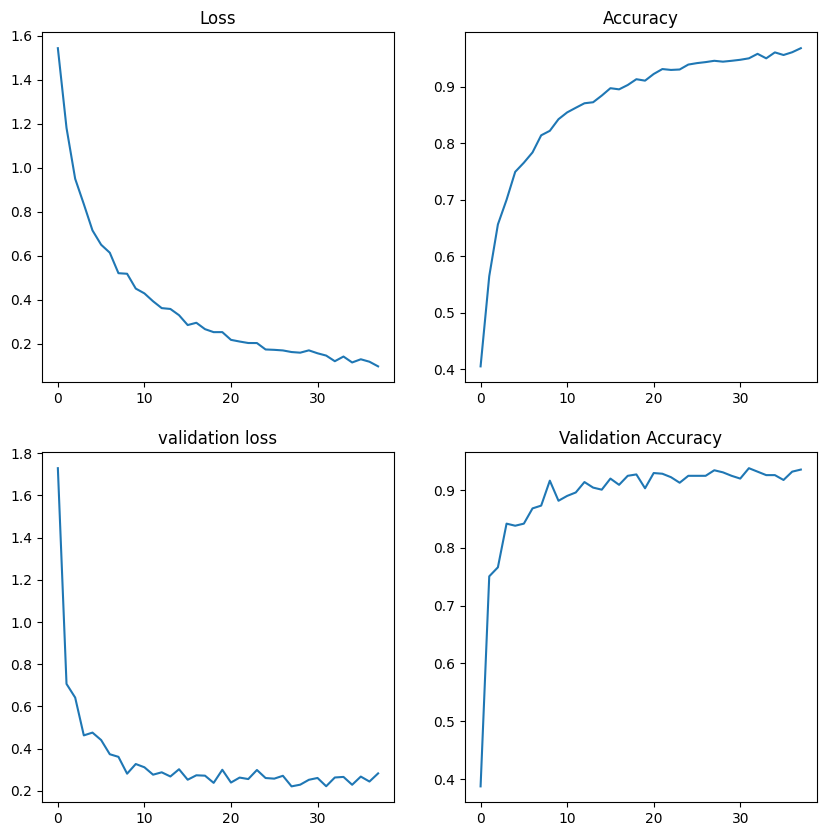

In [69]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
plt.subplot(2,2,1); plt.plot(model.history.history['loss']); plt.title('Loss')
plt.subplot(2,2,2); plt.plot(model.history.history['accuracy']); plt.title('Accuracy')
plt.subplot(2,2,3); plt.plot(model.history.history['val_loss']); plt.title('validation loss')
plt.subplot(2,2,4); plt.plot(model.history.history['val_accuracy']); plt.title('Validation Accuracy')
plt.show()

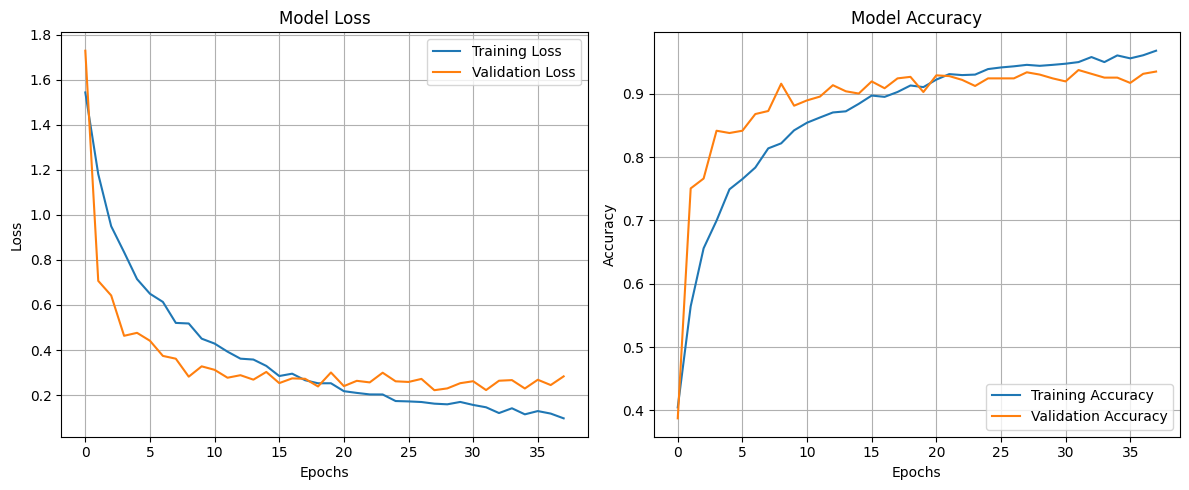

In [70]:
import matplotlib.pyplot as plt

# Create a figure with 2 subplots: one for loss, one for accuracy
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(model.history.history['loss'], label='Training Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(model.history.history['accuracy'], label='Training Accuracy')
plt.plot(model.history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# **Performance Anaylsis**

**creating test dataset from its directory**

In [71]:
test_dataset = image_classification_dataset_from_dataframe(
    test_df_cleaned,
    batch_size=batch_size,
    shuffle=False,
    pre_batching_processing=Resizing(img_height, img_width),
    post_batching_processing=None,
    do_normalization=True,
    class_mode='categorical'
)


For class 'Auto Rickshaws', there are 113 images.
For class 'Bikes', there are 120 images.
For class 'Cars', there are 118 images.
For class 'Motorcycles', there are 119 images.
For class 'Planes', there are 119 images.
For class 'Ships', there are 118 images.
For class 'Trains', there are 120 images.


**Evaluating the model**

In [72]:
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=True)
print('Test loss:', test_loss)
print('Test accuracy:', test_accuracy)


52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 263ms/step - accuracy: 0.9183 - loss: 0.2652
Test loss: 0.30683064460754395
Test accuracy: 0.9105199575424194


**Manual Single Image testing**

**Sample Test: Car**

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
[[1.6956024e-01 1.2762383e-06 8.2831043e-01 2.1267952e-03 4.6842018e-08
  7.1881641e-07 5.5831765e-07]]


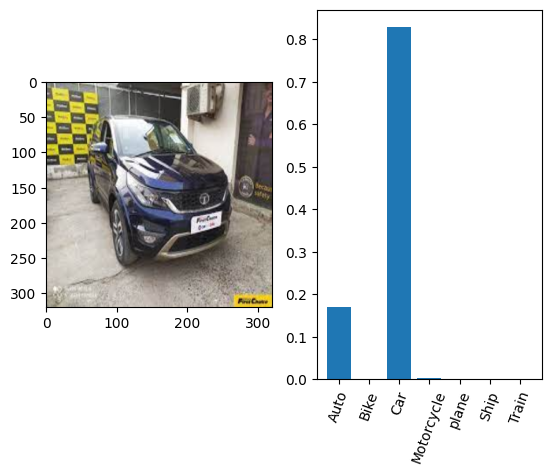

In [73]:
# test on one image
from skimage.transform import resize
import numpy as np
img = io.imread("/content/vehicle/Testing/Cars/Car (685).jpg")
img = np.float32(img)/255
img = resize(img, (img_height, img_width))
img = img.reshape((1, img_height, img_width, 3))
pred = model.predict(img)
print(pred)
plt.figure()
plt.subplot(1,2,1); plt.imshow(img[0])
plt.subplot(1,2,2); plt.bar(['Auto', 'Bike', 'Car','Motorcycle', 'plane','Ship','Train'], pred[0])
plt.xticks(rotation=70)
plt.show()


**Sample test: Auto**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[9.9998963e-01 1.4447138e-06 2.9627665e-06 4.7703004e-08 2.2276421e-07
  3.6270460e-08 5.6783347e-06]]


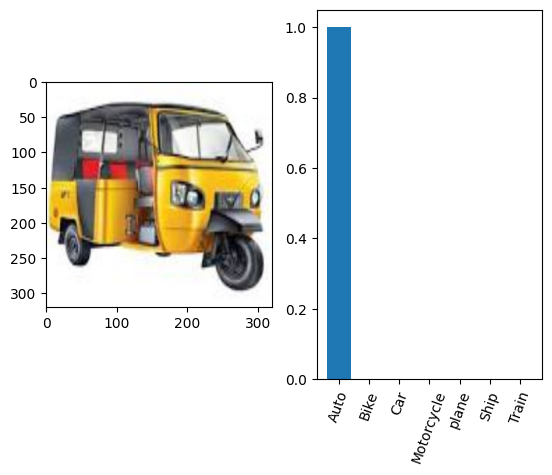

In [74]:
# test on one image
from skimage.transform import resize
import numpy as np
img = io.imread("/content/vehicle/Testing/Auto Rickshaws/Auto Rickshaw (691).jpg")
img = np.float32(img)/255
img = resize(img, (img_height, img_width))
img = img.reshape((1, img_height, img_width, 3))
pred = model.predict(img)
print(pred)
plt.figure()
plt.subplot(1,2,1); plt.imshow(img[0])
plt.subplot(1,2,2); plt.bar(['Auto', 'Bike', 'Car','Motorcycle', 'plane','Ship','Train'], pred[0])
plt.xticks(rotation=70)
plt.show()

**Sample test: Bike**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[5.1050236e-08 9.9999917e-01 8.3451749e-07 1.7512991e-10 1.8674022e-09
  4.6061409e-08 2.5453770e-09]]


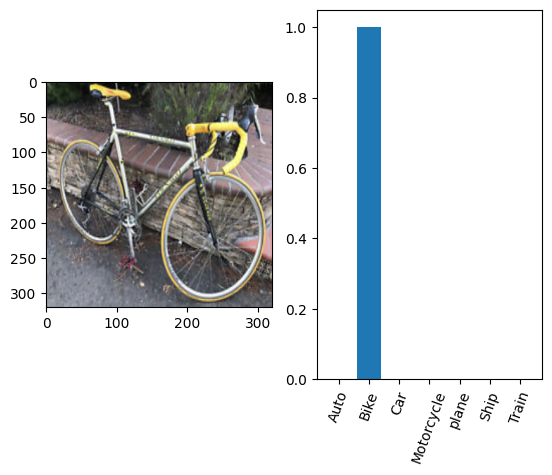

In [75]:
# test on one image
from skimage.transform import resize
import numpy as np
img = io.imread("/content/vehicle/Testing/Bikes/Bike (696).jpg")
img = np.float32(img)/255
img = resize(img, (img_height, img_width))
img = img.reshape((1, img_height, img_width, 3))
pred = model.predict(img)
print(pred)
plt.figure()
plt.subplot(1,2,1); plt.imshow(img[0])
plt.subplot(1,2,2); plt.bar(['Auto', 'Bike', 'Car','Motorcycle', 'plane','Ship','Train'], pred[0])
plt.xticks(rotation=70)
plt.show()

**Sample test: Motorcycle**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
[[6.03499620e-06 3.02401604e-04 1.13185756e-07 9.99193966e-01
  4.97515604e-04 4.13380867e-08 8.75824413e-10]]


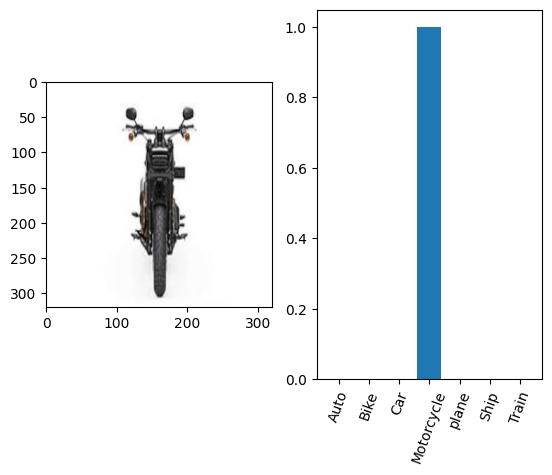

In [76]:
# test on one image
from skimage.transform import resize
import numpy as np
img = io.imread("/content/vehicle/Testing/Motorcycles/Motorcycle (708).jpg")
img = np.float32(img)/255
img = resize(img, (img_height, img_width))
img = img.reshape((1, img_height, img_width, 3))
pred = model.predict(img)
print(pred)
plt.figure()
plt.subplot(1,2,1); plt.imshow(img[0])
plt.subplot(1,2,2); plt.bar(['Auto', 'Bike', 'Car','Motorcycle', 'plane','Ship','Train'], pred[0])
plt.xticks(rotation=70)
plt.show()

**Sample Test: plane**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[[2.8071368e-06 1.5758537e-04 1.1937293e-06 4.8505211e-07 9.9982029e-01
  1.7295280e-05 4.0962740e-07]]


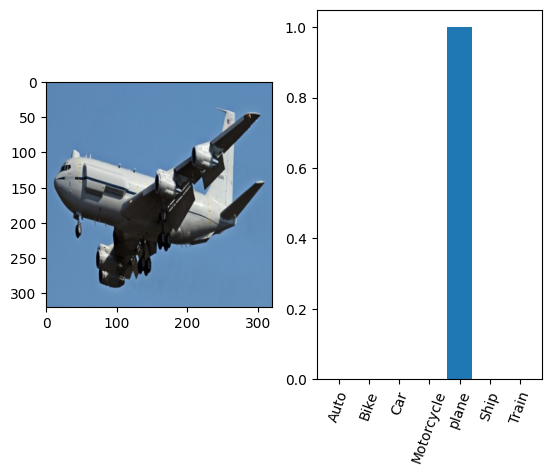

In [77]:
# test on one image
from skimage.transform import resize
import numpy as np
img = io.imread("/content/vehicle/Testing/Planes/Plane (711).jpg")
img = np.float32(img)/255
img = resize(img, (img_height, img_width))
img = img.reshape((1, img_height, img_width, 3))
pred = model.predict(img)
print(pred)
plt.figure()
plt.subplot(1,2,1); plt.imshow(img[0])
plt.subplot(1,2,2); plt.bar(['Auto', 'Bike', 'Car','Motorcycle', 'plane','Ship','Train'], pred[0])
plt.xticks(rotation=70)
plt.show()

**Sample test: ship**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
[[2.49610603e-05 1.05951396e-04 2.59238295e-05 7.24706479e-05
  2.29880257e-04 9.99540091e-01 7.45630359e-07]]


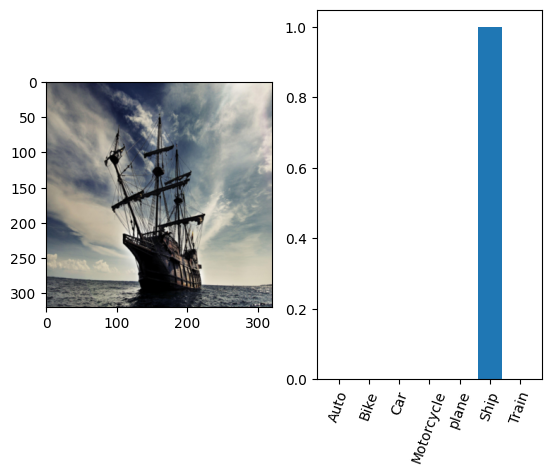

In [78]:
# test on one image
from skimage.transform import resize
import numpy as np
img = io.imread("/content/vehicle/Testing/Ships/Ship (713).jpg")
img = np.float32(img)/255
img = resize(img, (img_height, img_width))
img = img.reshape((1, img_height, img_width, 3))
pred = model.predict(img)
print(pred)
plt.figure()
plt.subplot(1,2,1); plt.imshow(img[0])
plt.subplot(1,2,2); plt.bar(['Auto', 'Bike', 'Car','Motorcycle', 'plane','Ship','Train'], pred[0])
plt.xticks(rotation=70)
plt.show()

**Sample Test: Train**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
[[1.0485849e-04 4.1262709e-07 9.3113769e-05 4.5145651e-08 8.5260517e-06
  7.9018969e-07 9.9979228e-01]]


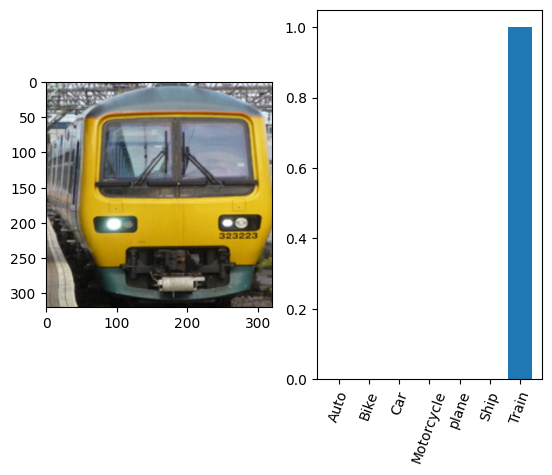

In [79]:
# test on one image
from skimage.transform import resize
import numpy as np
img = io.imread("/content/vehicle/Testing/Trains/Train (706).png")
img = np.float32(img)/255
img = resize(img, (img_height, img_width))
img = img.reshape((1, img_height, img_width, 3))
pred = model.predict(img)
print(pred)
plt.figure()
plt.subplot(1,2,1); plt.imshow(img[0])
plt.subplot(1,2,2); plt.bar(['Auto', 'Bike', 'Car','Motorcycle', 'plane','Ship','Train'], pred[0])
plt.xticks(rotation=70)
plt.show()

**Sample test: Indian Auto Vehicle**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
[[9.80327308e-01 4.97835526e-06 1.65216830e-02 1.59530944e-04
  1.33451889e-03 1.06875505e-05 1.64137362e-03]]


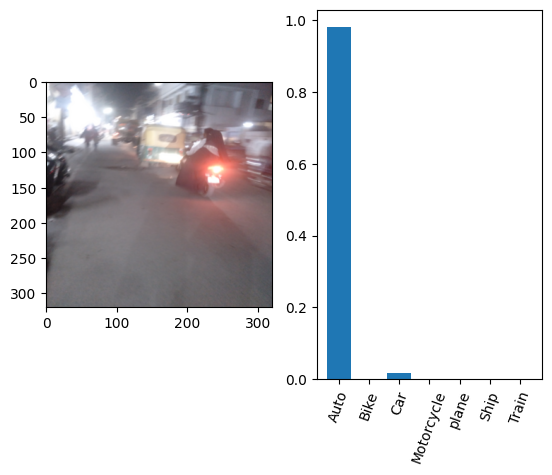

In [80]:
# test on one image
from skimage.transform import resize
import numpy as np
img = io.imread("/content/drive/MyDrive/Colab Notebooks/Datacluster Auto (133).jpg")
img = np.float32(img)/255
img = resize(img, (img_height, img_width))
img = img.reshape((1, img_height, img_width, 3))
pred = model.predict(img)
print(pred)
plt.figure()
plt.subplot(1,2,1); plt.imshow(img[0])
plt.subplot(1,2,2); plt.bar(['Auto', 'Bike', 'Car','Motorcycle', 'plane','Ship','Train'], pred[0])
plt.xticks(rotation=70)
plt.show()

**Sample test: Egyptian Train**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
[[1.8335080e-02 5.1596562e-06 1.2306287e-03 1.9773382e-03 1.1799589e-02
  4.2228198e-01 5.4437023e-01]]


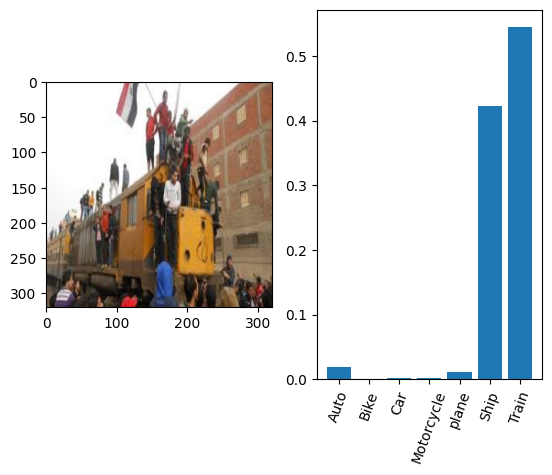

In [81]:
from skimage.transform import resize
import numpy as np
img = io.imread("/content/drive/MyDrive/Colab Notebooks/train.jfif")
img = np.float32(img)/255
img = resize(img, (img_height, img_width))
img = img.reshape((1, img_height, img_width, 3))
pred = model.predict(img)
print(pred)
plt.figure()
plt.subplot(1,2,1); plt.imshow(img[0])
plt.subplot(1,2,2); plt.bar(['Auto', 'Bike', 'Car','Motorcycle', 'plane','Ship','Train'], pred[0])
plt.xticks(rotation=70)
plt.show()

**Sample test: Egyptian Ship**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
[[7.0403767e-06 4.1836915e-06 4.7890367e-03 1.8289843e-07 7.2503573e-04
  9.9438995e-01 8.4531712e-05]]


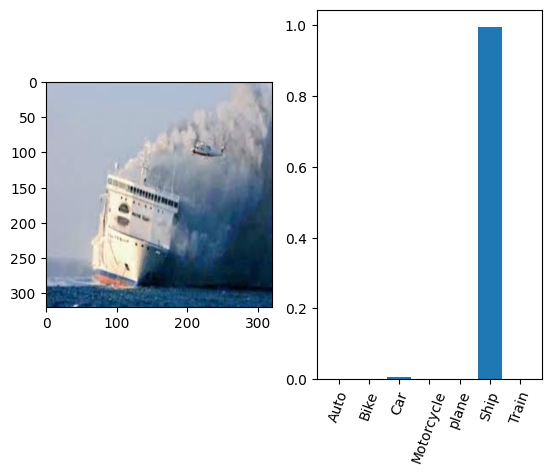

In [82]:
from skimage.transform import resize
import numpy as np
img = io.imread("/content/drive/MyDrive/Colab Notebooks/Tship.jfif")
img = np.float32(img)/255
img = resize(img, (img_height, img_width))
img = img.reshape((1, img_height, img_width, 3))
pred = model.predict(img)
print(pred)
plt.figure()
plt.subplot(1,2,1); plt.imshow(img[0])
plt.subplot(1,2,2); plt.bar(['Auto', 'Bike', 'Car','Motorcycle', 'plane','Ship','Train'], pred[0])
plt.xticks(rotation=70)
plt.show()

**Sample test: Personal Motorcycle**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[2.0261945e-02 4.4218265e-03 1.4207535e-03 9.6726674e-01 4.3898877e-03
  1.7900494e-03 4.4892958e-04]]


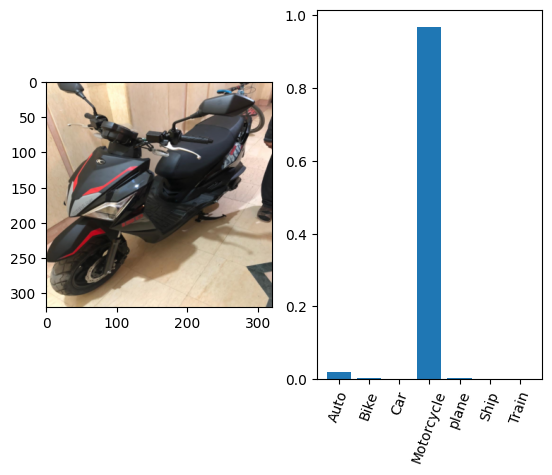

In [83]:
from skimage.transform import resize
import numpy as np
img = io.imread("/content/drive/MyDrive/Colab Notebooks/WhatsApp Image 2025-06-07 at 1.59.36 PM.jpeg")
img = np.float32(img)/255
img = resize(img, (img_height, img_width))
img = img.reshape((1, img_height, img_width, 3))
pred = model.predict(img)
print(pred)
plt.figure()
plt.subplot(1,2,1); plt.imshow(img[0])
plt.subplot(1,2,2); plt.bar(['Auto', 'Bike', 'Car','Motorcycle', 'plane','Ship','Train'], pred[0])
plt.xticks(rotation=70)
plt.show()

**Sample test: Egyptian Auto**

**Sample test: Egyptian Train**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[2.6957294e-02 1.8702335e-06 4.1296193e-03 1.2318319e-02 9.1188158e-05
  2.9076458e-04 9.5621091e-01]]


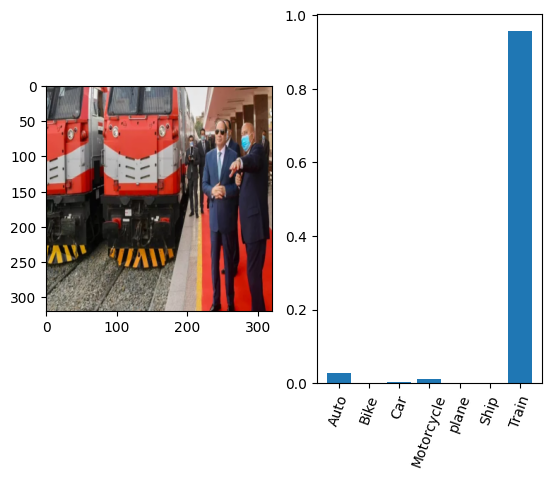

In [85]:
from skimage.transform import resize
import numpy as np
img = io.imread("/content/drive/MyDrive/Colab Notebooks/sisi_503.jpg.webp")
img = np.float32(img)/255
img = resize(img, (img_height, img_width))
img = img.reshape((1, img_height, img_width, 3))
pred = model.predict(img)
print(pred)
plt.figure()
plt.subplot(1,2,1); plt.imshow(img[0])
plt.subplot(1,2,2); plt.bar(['Auto', 'Bike', 'Car','Motorcycle', 'plane','Ship','Train'], pred[0])
plt.xticks(rotation=70)
plt.show()

**Sample Test: Egyptian Airplane**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[4.5740686e-07 1.8551119e-02 2.8750133e-05 3.3897472e-06 9.8140854e-01
  7.2890875e-06 4.4347942e-07]]


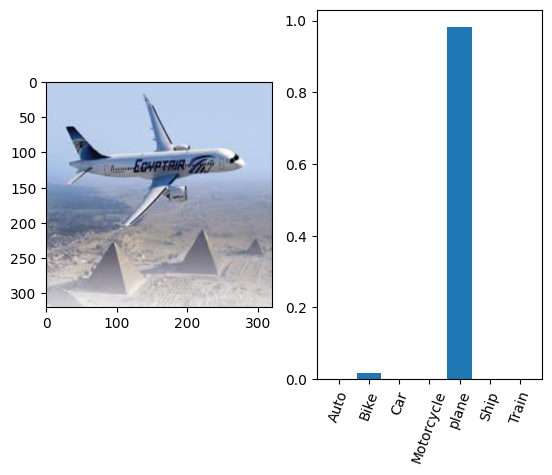

In [86]:
from skimage.transform import resize
import numpy as np
img = io.imread("/content/drive/MyDrive/Colab Notebooks/airplane.jfif")
img = np.float32(img)/255
img = resize(img, (img_height, img_width))
img = img.reshape((1, img_height, img_width, 3))
pred = model.predict(img)
print(pred)
plt.figure()
plt.subplot(1,2,1); plt.imshow(img[0])
plt.subplot(1,2,2); plt.bar(['Auto', 'Bike', 'Car','Motorcycle', 'plane','Ship','Train'], pred[0])
plt.xticks(rotation=70)
plt.show()